In [1]:
'''
Read a set of datafiles, each containing datawords obtained by putting a sweep of 
voltages (1.8V to 0) into the ADC bypassing the CSA. These voltages should result
in a good dataword range from 200 to 800 or so. Two arrays are created and written
to a file for later analysis:
    pkt_count: logs the # of packets in each word bin by channel
    too_few: logs the # of word bins with < 2 packets by channel
'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math
import tqdm

from tqdm import tqdm
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime

##########################################################
# Initialize parameters  
##########################################################

#files = ["../data/test_gain_t3_20thresh.hdf5"] # successfully only tested 1 channel on all t3 chips
files = ["../data/packet-warm_gain_t3_540s_128dac_20thresh.hdf5"]
#files = ["../data/packet-warm_gain_t3_600s_128dac_60thresh.hdf5"]

dacs = [128]
high_word = 1000
low_word = 500

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7]

# serial numbers for set 1-7
chip_serial_number_list = ['', '4k02056', '4k603591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101' ]
ntiles = 7

# initialize
ig = 1 
first_tile = True
pkt_count = [[[0 for wrd in range(1023)] for chn in range(64)] for chp in range(256)]

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp'

In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def get_data(files, tile, ig):
    
    global pkt_count, chip_serial_number, temp, total_livetime
    
    # initialize at the tile level
    verbose = False
    first_file = True
    
    # read packet data from each file 
    for filename in files:

        if first_file:
            first_file = False
            
            # read packets from the file
            f = h5py.File(filename, 'r')
            packets = f['packets'][:]

            # create arrays of data packets
            data_mask = f['packets'][:]['packet_type']  == 1
            data_pkts = packets[data_mask]

            # determine the runtime of the file
            unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
            livetime = np.max(unixtime)-np.min(unixtime)        

            total_livetime = livetime
            
            print(f"\t{len(data_pkts):,} data packets gathered over {livetime}s in {filename}")

            # determine if this was a warm or cold data run (info for filename)
            if "warm" in filename:
                temp = "warm"
            elif "cold" in filename:
                temp = "cold"
            else:
                print(f"Problem: the file name does not indicate warm or cold")
                temp = "unknown_temperature"     
        
        else:
            f = h5py.File(filename, 'r')
            packets = f['packets'][:]
            data_mask = f['packets'][:]['packet_type']  == 1
            extra_data_pkts = packets[data_mask]

            unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
            livetime = np.max(unixtime)-np.min(unixtime)        

            total_livetime += livetime
            
            print(f"\t{len(extra_data_pkts):,} data packets gathered over {livetime}s in {filename}")            

            data_pkts = np.concatenate( (data_pkts, extra_data_pkts), axis=0 )
    
    for io_ch in range(41):

        # mask for io_channel
        ioch_mask = data_pkts['io_channel'] == io_ch
        ioch_pkts = data_pkts[ioch_mask]  

        ioch_counts = len(ioch_pkts)

        if ioch_counts > 0:
            print(f"\tio_channel {io_ch} had {ioch_counts} data pkts")
    
    # get a list of the io_channels that could be enabled for a given tile
    io_channel_ids = get_io_channels(tile)

    print(f"\tTile {tile}, masking for IO_channels: {io_channel_ids}")
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]
    
    # check for tiles with no data    
    if len(data_pkts) ==0: 
        print(f'There are no data packets for tile {tile}')        
        return

    # remove data packets with zero datawords
    non_zero_pkts = data_pkts[data_pkts['dataword'] != 0]

    print(f"\t{len(non_zero_pkts):,} non-zero dataword packets")
        
    # populate lists/arrays containing the # of packets in each word bin per channel
    for chip in tqdm(range(11,171), desc = "counting pkts by chip"):
            
        # mask for chip
        chip_mask = non_zero_pkts['chip_id'] == chip
        chip_pkts = non_zero_pkts[chip_mask]     
            
        #if len(chip_pkts) == 0:
        #    print(f"There are 0 non-zero packets in chip {chip}")
        #    continue
            
        for chan in range(64):
    
            # mask for channel    
            chan_mask = chip_pkts['channel_id'] == chan
            chan_adc = chip_pkts[chan_mask]['dataword'][:]            
            
            #if len(chan_adc) == 0:
            #    print(f"There are 0 non-zero packets in chip-chan {chip}-{chan}")
            #    continue
            
            # record bin counts
            for word in range(240, 800):
                pkt_count[chip][chan][word] = chan_adc.tolist().count(word)
    
    return

In [4]:
def graph_tile(tile):

    global pkt_count, chip_serial_number, temp, dacs, high_word, low_word

    chip_count_list, word_count_list, chip_list, word_list = [], [], [], []
    chan_counts = [0 for chan in range(64)]
    chan_count_list, chan_list = [], [] 
    n_chips = 0
    noisy_chips = []
    main_counts = []

    bad_chip_list, bad_chan_list = [], []
    
    for chip in range(11,171):
        count_list_all_words = np.array(pkt_count[chip]).flatten()
        chip_count_list.append(np.sum(count_list_all_words))
        chip_list.append(chip)

        for chan in range(64):
            chan_counts[chan]+= sum(pkt_count[chip][chan])
            for word in range(260, 800):
                if pkt_count[chip][chan][word] > 0:
                    word_count_list.append(pkt_count[chip][chan][word])
                    word_list.append(word)
                    if word not in range(low_word, high_word):
                        bad_chip_list.append(chip)
                        bad_chan_list.append(chan)

    mode_chip_count_list = mode(chip_count_list)
    print(f"Mode count per chip = {mode_chip_count_list:.1f}")    

    # identify noisy chips
    for chip in range(11,171):     
        count_list_all_words = np.array(pkt_count[chip]).flatten()
        npkts = np.sum(count_list_all_words)
    
        if npkts > 0:
            n_chips +=1
            if npkts < mode_chip_count_list * 1.5:
                main_counts.append(npkts)
            else:
                noisy_chips.append(chip)
                print(f"Tile-chip {tile}-{chip} had an abnormally large # packets ({npkts})")
    
    for chan in range(64):
        chan_list.append(chan)
        chan_count_list.append(chan_counts[chan])

    mode_chan_count_list = mode(chan_count_list) / n_chips
    print(f"Mode count per channel = {mode_chan_count_list:.1f}")

    mode_chip_count_list = mode(chip_count_list)
    print(f"Mode count per chip = {mode_chip_count_list:.1f}")    
    
    fig, ax = plt.subplots(1,2, figsize=(12, 3))

    ax[0].set_title(f'# Packets by Chip (mode = {mode_chip_count_list}) \ndacs = {dacs} v3a Tile #{tile} ({chip_serial_number})')    
    ax[0].plot(chip_list, chip_count_list, marker = 'o', linestyle = '')
    ax[0].set_yscale("log")   
    ax[0].set_xlabel(f'Chip')
    ax[0].set_ylabel(f'# pkts')

    nbins = max(main_counts) - min(main_counts) +1    
    ax[1].set_title(f'Zoom in on # Pkts by Chip (mode = {mode_chip_count_list})\ndacs = {dacs} v3a Tile #{tile} ({chip_serial_number})')
    ax[1].hist(main_counts, bins = nbins)
    ax[1].set_yscale("log")   
    ax[1].axvline(x = mode_chip_count_list, color='r', linestyle='--', linewidth=2) 
    ax[1].set_xlabel(f'# Packets')
    ax[1].set_ylabel(f'# Chips')
    plt.show
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(word_list, word_count_list)
    ax.set_title(f'# Packets by Word on Tile {tile}\ndacs = {dacs} v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Dataword')
    ax.set_ylabel(f'# Packets')
    ax.set_yscale("log")
    plt.show     
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(chan_list, chan_count_list, marker='o', linestyle='')
    ax.set_title(f'# Packets by Channel on Tile {tile} (mode {mode_chan_count_list})\ndacs = {dacs} v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Channel')
    ax.set_ylabel(f'# pkts')
    plt.show 
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(bad_chip_list, bad_chan_list, alpha = 0.2)
    ax.set_title(f'Channels with Datawords outside range({low_word}, {high_word})\n Red Lines indicate Particularly Noisy Chips\n Tile {tile}, dacs = {dacs}, v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Chip')
    ax.set_ylabel(f'Channel')
    for chip in noisy_chips:
        ax.axvline(x = chip, color='r', linestyle='--')         
    plt.show 

    # print set of bad chips
    bad_chip_list = list(dict.fromkeys(bad_chip_list))
    print(f"\nChips with words outside range({low_word}, {high_word}): \n{bad_chip_list}")
    

In [5]:
def graph_chip(tile, chip, focus_chan):

    global pkt_count, chip_serial_number, temp, dacs

    chan_count_list, chan_list = [], []  
    word_count_list, word_list = [], []  
    
    for chan in range(64):       
        chan_list.append(chan)
        chan_count_list.append(sum(pkt_count[chip][chan]))

    if sum(chan_count_list) ==0:
        print(f"Chip {chip} has no packets")
        return
    else:
        print(f"\nFocus Chip-Chan {chip}-{chan}:") 
    
    for word in range(0, 1023):
        if pkt_count[chip][focus_chan][word] > 0:
            word_count_list.append(pkt_count[chip][focus_chan][word])
            word_list.append(word)
            #print(f"\tword, pkt_count = {word}, {pkt_count[chip][focus_chan][word]}")

    print(f"Mean count per channel on tile-chip {tile}-{chip} = {np.mean(chan_count_list):.1f}")
    print(f"Word range on tile-chip {tile}-{chip} {min(word_list), max(word_list)}")
    
    fig, ax = plt.subplots(1,2, figsize=(12, 3))

    ax[0].plot(chan_list, chan_count_list, marker='o', linestyle = '')
    ax[0].set_title(f'# Packets by Channel on tile-chip {tile}-{chip}\ndacs = {dacs} v3a Tile #{tile} ({chip_serial_number})')
    ax[0].set_xlabel(f'Channel')
    ax[0].set_ylabel(f'# pkts')
    
    ax[1].bar(word_list, word_count_list)
    ax[1].set_title(f'# Packets by Word on Tile-Chip-Chan {tile}-{chip}-{focus_chan}\ndacs = {dacs} v3a Tile #{tile} ({chip_serial_number})')
    ax[1].set_xlabel(f'Dataword')
    ax[1].set_ylabel(f'# Packets')
    ax[1].set_yscale("log")

    plt.show 


In [6]:
####################
# main
####################

print(f'Run Statistics for {len(files)} Data Files:')

# use the filename of the 1st file to determine the tile tested in these runs
filename = files[0]

if "_t1_" in filename:
    tile = 1
elif "_t2_" in filename:
    tile = 2
elif "_t3_" in filename:
    tile = 3
elif "_t4_" in filename:
    tile = 4
elif "_t5_" in filename:
    tile = 5
elif "_t6_" in filename:
    tile = 5
elif "_t7_" in filename:
    tile = 7
else:
    print("PROBLEM: the tile # is not identified in the datafile name")

chip_serial_number = chip_serial_number_list[tile]

get_data(files, tile, ig)

Run Statistics for 1 Data Files:
	995,283 data packets gathered over 590s in ../data/packet-warm_gain_t3_540s_128dac_20thresh.hdf5
	io_channel 9 had 24320 data pkts
	io_channel 10 had 917483 data pkts
	io_channel 11 had 53480 data pkts
	Tile 3, masking for IO_channels: [9, 10, 11, 12]
	995,019 non-zero dataword packets


counting pkts by chip: 100%|█████████████████████████████████████████████████████████████████| 160/160 [00:09<00:00, 17.06it/s]


Mode count per chip = 640.0
Tile-chip 3-22 had an abnormally large # packets (1604)
Tile-chip 3-55 had an abnormally large # packets (1249)
Tile-chip 3-91 had an abnormally large # packets (891849)
Mode count per channel = 10.0
Mode count per chip = 640.0

Chips with words outside range(500, 1000): 
[13, 15, 16, 20, 21, 22, 25, 26, 28, 29, 32, 33, 34, 35, 39, 43, 47, 49, 50, 51, 53, 55, 56, 57, 58, 60, 61, 62, 65, 66, 71, 72, 74, 76, 79, 80, 81, 84, 86, 87, 91, 92, 97, 98, 99, 102, 105, 106, 107, 109, 117, 121, 123, 125, 127, 128, 139, 146, 148, 150, 153, 154, 155, 156, 158, 159, 162, 164, 165, 167, 168, 170]


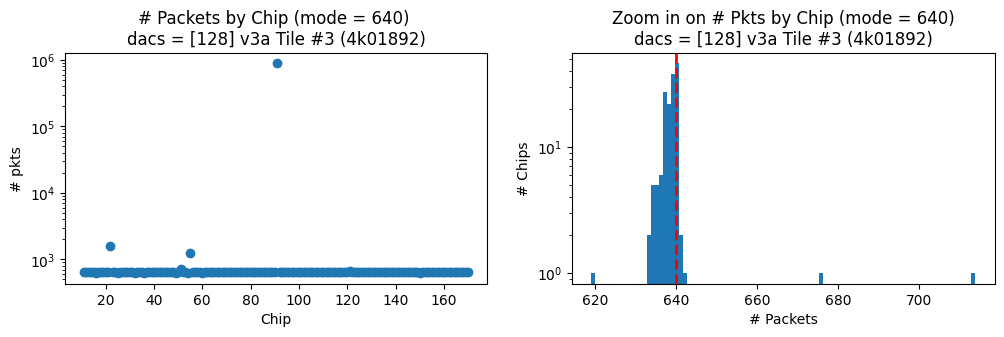

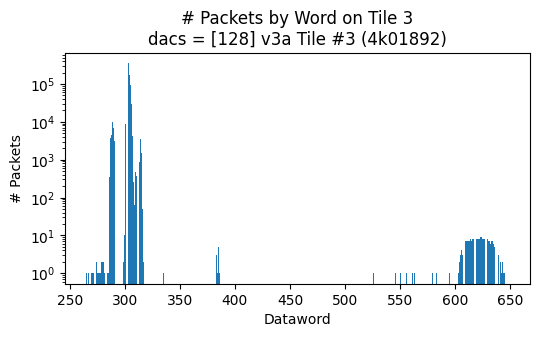

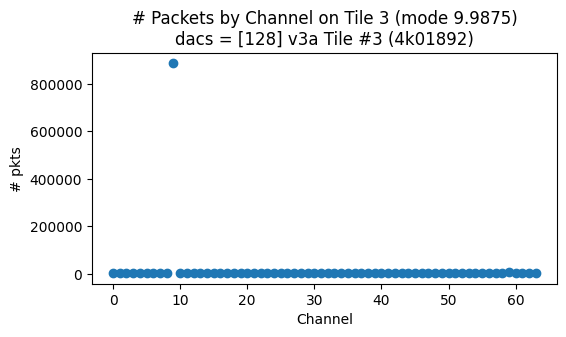

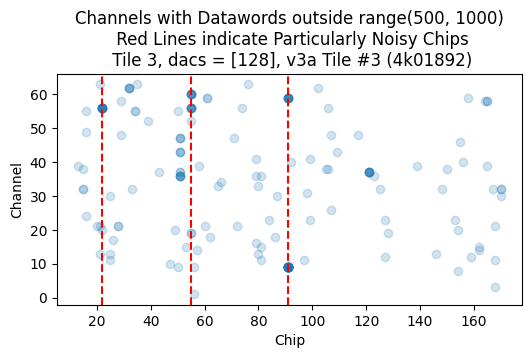

In [7]:
graph_tile(tile)


Focus Chip-Chan 91-63:
Mean count per channel on tile-chip 3-91 = 13935.1
Word range on tile-chip 3-91 (285, 604)


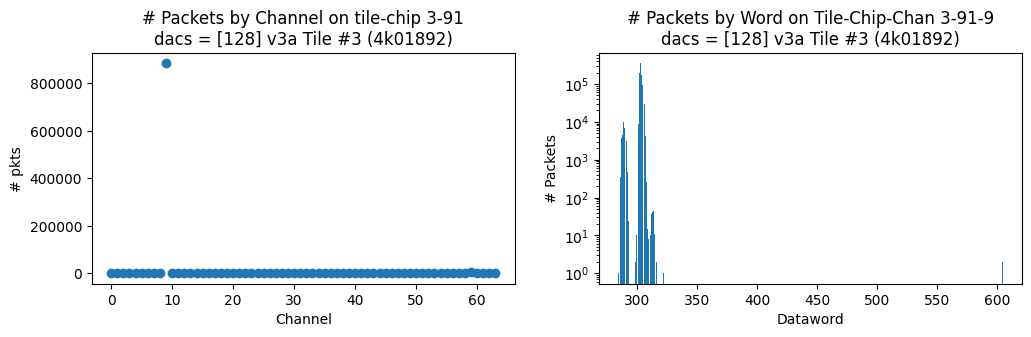

In [8]:
graph_chip(tile, 91, 9)